In [28]:
from langgraph.graph import StateGraph,START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.types import interrupt

from psycopg_pool import ConnectionPool
from langgraph.checkpoint.postgres import PostgresSaver

from pydantic import BaseModel,Field
from typing import List, Dict, Any, Annotated, Optional,Literal

import requests

from dotenv import load_dotenv
import os
load_dotenv()

model = ChatOpenAI(model_name="gpt-5.4-nano", temperature=0.5, openai_api_key=os.getenv("OPENAI_API_KEY"))

In [29]:
class EmailState(StateGraph):
    email_id :str
    sender :str
    subject :str
    body :str
    
    category :str
    priority :str
    action :str
    confidence :float
    requires_human_intervention :bool
    reason: str
    approval : dict
    

In [30]:
class email_decision(BaseModel):
    
    category :str = Field(..., description="Category of the email")
    priority :str = Field(..., description="Priority of the email")
    action :str = Field(..., description="Action to be taken for the email")
    confidence :float = Field(..., description="Confidence level of the decision")
    requires_human_intervention :bool = Field(..., description="Whether the email requires human intervention")
    reason :str = Field(..., description="Reason for the decision")

In [31]:
analysis_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are an AI Operations Analyst working inside an enterprise Operations Command Center.

Your responsibility is to analyze incoming emails, understand the user's intent, 
assess business impact, and recommend the appropriate next action.

Analyze each email based on:

1. Category:
   Identify the business domain of the request.
   Examples:
   - billing
   - customer_support
   - technical_issue
   - sales
   - account_management
   - security
   - complaint
   - general_inquiry

2. Priority:
   Determine urgency and business impact.

   Rules:
   - critical: Security risks, system outages, legal issues, major customer impact
   - high: Important customer/business requests requiring quick attention
   - medium: Normal operational requests
   - low: Informational requests or non-urgent matters

3. Recommended Action:
   Decide what should happen next.

   Examples:
   - reply_to_customer
   - create_support_ticket
   - update_crm
   - escalate_to_team
   - request_more_information
   - schedule_followup
   - no_action_required

4. Human Intervention:
   Decide if a human approval or review is required.

   Human intervention is required when:
   - The request involves financial decisions
   - There are security concerns
   - A customer complaint is severe
   - A contract/legal decision is involved
   - The confidence of the decision is low

5. Reasoning:
   Provide a short explanation for your decision.

You must return ONLY valid JSON.
Do not include markdown, explanations outside JSON, or additional text.

Required JSON format:

{{
    "category": "string",
    "priority": "critical|high|medium|low",
    "action": "string",
    "requires_human": true|false,
    "confidence": 0.0-1.0,
    "reason": "short explanation"
}}
"""
    ),

    (
        "user",
        """
Analyze this incoming email:

Subject:
{subject}

Body:
{body}
"""
    )
])

In [32]:
def analyse_email(state: EmailState):
    
    chain =  analysis_prompt | model.with_structured_output(email_decision)
    resp = chain.invoke({"subject": state['subject'], "body": state['body']})
    
    
    return {"category": resp.category, "priority": resp.priority, "action": resp.action, "requires_human_intervention": resp.requires_human_intervention, "confidence": resp.confidence, "reason": resp.reason}
    
    
    

In [33]:
def human_approval(state: EmailState):
    print(f"Email ID: {state['email_id']} require human approval.")
    return {"reason": state['reason'] + "about to get approved for the action."}
    
    

In [34]:

def execute_action(state: EmailState):
 
    WEBHOOK_URL = 'http://localhost:5678/webhook/39e7c9a8-f0e0-42cc-86af-5e54d67094b7'

    response = requests.post(WEBHOOK_URL, json=state)
    
    return state

In [35]:
def action_decision(state: EmailState) -> Literal["human_approval", "execute_action"]:
    if state['requires_human_intervention']:
        return "human_approval"
    else:
        return "execute_action"

In [36]:
graph = StateGraph(EmailState) 


DB_URL = os.getenv("DATABASE_URL")
   
connection_pool = ConnectionPool(conninfo=DB_URL)
checkpointer = PostgresSaver(connection_pool)

graph.add_node("analyse_email",analyse_email)
graph.add_node("human_approval",human_approval)
graph.add_node("execute_action",execute_action)

graph.add_edge(START, "analyse_email")
graph.add_conditional_edges("analyse_email", action_decision)
graph.add_edge("human_approval", 'execute_action')
graph.add_edge("execute_action", END)

workflow = graph.compile(checkpointer=checkpointer)


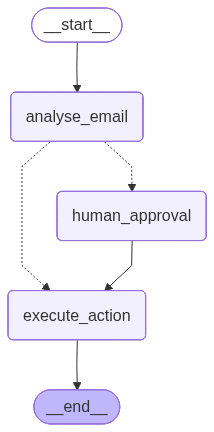

In [37]:
workflow

In [38]:
inp = {"email_id": "12345", "sender": 'sajid', "subject": 'Serious issue', "body": 'My bank card have lost. I need urgent support', "category": '', "priority": '', "action": '', "requires_human_intervention": False}

In [39]:
config = {"configurable":{"thread_id":f"email_{inp['email_id']}"}}
result = workflow.invoke(inp,config=config)

Email ID: 12345 require human approval.


In [40]:
result

{'email_id': '12345',
 'sender': 'sajid',
 'subject': 'Serious issue',
 'body': 'My bank card have lost. I need urgent support',
 'category': 'account_management',
 'priority': 'high',
 'action': 'create_support_ticket',
 'confidence': 0.78,
 'requires_human_intervention': True,
 'reason': 'Customer reports lost bank card and requests urgent support; potential financial/account security impact requiring prompt human handling.about to get approved for the action.'}

In [41]:
workflow.get_state(config=config)

StateSnapshot(values={'email_id': '12345', 'sender': 'sajid', 'subject': 'Serious issue', 'body': 'My bank card have lost. I need urgent support', 'category': 'account_management', 'priority': 'high', 'action': 'create_support_ticket', 'confidence': 0.78, 'requires_human_intervention': True, 'reason': 'Customer reports lost bank card and requests urgent support; potential financial/account security impact requiring prompt human handling.about to get approved for the action.'}, next=(), config={'configurable': {'thread_id': 'email_12345', 'checkpoint_ns': '', 'checkpoint_id': '1f17c7e6-922d-6644-8013-1d659bb18730'}}, metadata={'step': 19, 'source': 'loop', 'parents': {}}, created_at='2026-07-10T16:42:59.680906+00:00', parent_config={'configurable': {'thread_id': 'email_12345', 'checkpoint_ns': '', 'checkpoint_id': '1f17c7e6-913d-669b-8012-03549f287fc4'}}, tasks=(), interrupts=())